# 1. Setup and Data Preparation
Prepare the runtime environment and load the preprocessed dataset for training.

## Mount Google Drive
Mount Google Drive so the notebook can access the shared dataset archive and any saved outputs.

In [89]:
import sys

# 若在 Colab 環境執行，才掛載 Google Drive
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("非 Colab 環境 (本機執行)，跳過掛載 Google Drive。")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Extract the Dataset Archive
Unzip the preprocessed dataset into the Colab runtime so file access is fast during training and evaluation.

In [90]:
import os
import sys

# 僅在 Colab 環境執行解壓縮
if 'google.colab' in sys.modules:
    # 將雲端硬碟的 .zip 檔解壓縮到 Colab 本地空間 (讀取速度最快)
    zip_path = "/content/drive/MyDrive/Hand_gestures/dataset_v3_processed_detected.zip"
    extract_path = "/content/processed_hagrid_small"

    if os.path.exists(zip_path) and not os.path.exists(extract_path):
        print("解壓縮資料集至 Colab 空間中！ (這會大幅提升訓練速度)...")
        # 加上 -o 參數，如果檔案存在就直接蓋過去，不要跳出詢問視窗卡死
        !unzip -q -o "{zip_path}" -d /content/
        print("解壓縮完成！")
    elif os.path.exists(extract_path):
        print("資料集已解壓縮過了，跳過解壓縮。")
    else:
        print(f"請確認您的雲端硬碟根目錄真的有 {zip_path} 這個檔案！")
else:
    print("本機環境，跳過解壓縮。請確保資料集已經放在正確的資料夾中。")

解壓縮資料集至 Colab 空間中！ (這會大幅提升訓練速度)...
解壓縮完成！


## Load the Manifest Table
Read the CSV manifest and normalize stored file paths so they point to the extracted Colab dataset location.

In [91]:
import pandas as pd
from pathlib import Path

# Colab 測試時的預設解壓縮路徑
DATA_CSV = Path("/content/labels.csv")

if not DATA_CSV.exists():
    # 本機測試時的備用路徑 (Windows / Mac) D:\Hand_Gesture\data\processed_hagrid_small_detect
    DATA_CSV = Path("dataset_v3_processed_detected/labels.csv")
    if not DATA_CSV.exists():
        # 如果還是找不到，可以修改這個絕對路徑 (例如 Windows D 槽)
        DATA_CSV = Path("D:/Hand_Gesture/data/dataset_v2_processed_detected/labels.csv")

df = pd.read_csv(DATA_CSV)

# === 修復路徑：支援各平台 ===
# 無論 CSV 內存的是 Mac 還是 Windows 的絕對路徑
# 統一拿相對結構 "crops/檔名" 組合上目前 CSV 實際所在的資料夾
base_dir = DATA_CSV.parent

def fix_path_cross_platform(path_str):
    if pd.isna(path_str): return path_str
    # 解決 Unix 下讀取 Windows 反斜線會被當成檔名的問題
    path_str = path_str.replace("\\", "/")
    p_path = Path(path_str)
    # 取出 "crops/檔名" 或 "landmarks/檔名"，與真正的 base_dir 結合
    return str(base_dir / p_path.parent.name / p_path.name)

df["crop_path"] = df["crop_path"].apply(fix_path_cross_platform)
df["landmark_path"] = df["landmark_path"].apply(fix_path_cross_platform)

print("using:", DATA_CSV)
print(df.head())
print("total:", len(df))
print(df["label_name"].value_counts())
print(df["label"].value_counts().sort_index())

using: /content/labels.csv
                                                 idx original_class_folder  \
0  take_picture_b1246073-2422-4eb4-a0e4-8fbf046be852          take_picture   
1         peace_8a738072-e2fd-40fe-becf-73e6bb40bcf2                 peace   
2   thumb_index_b2e5c3c8-c3c4-4ff4-9151-2c24a51d1a1d           thumb_index   
3          four_e2ea91a3-60d3-491a-88c9-2e902b136fab                  four   
4            ok_db83a94f-db45-48bf-8555-7a3b25a26e4b                    ok   

   label label_name                                          crop_path  \
0      0        N_A  /content/crops/take_picture_b1246073-2422-4eb4...   
1      0        N_A  /content/crops/peace_8a738072-e2fd-40fe-becf-7...   
2      0        N_A  /content/crops/thumb_index_b2e5c3c8-c3c4-4ff4-...   
3      0        N_A  /content/crops/four_e2ea91a3-60d3-491a-88c9-2e...   
4      3         ok  /content/crops/ok_db83a94f-db45-48bf-8555-7a3b...   

                                       landmark_path qualit

## Split: Training / Validation / Testing
Create stratified train, validation, and test splits so each class keeps a similar distribution across all subsets.

In [92]:
from sklearn.model_selection import train_test_split

SEED = 42

# 如果需要測試用少量樣本，可以取消註解底下這行覆寫：
# df = pd.read_csv("D:/Hand_Gesture/data/processed_sample/labels.csv")

# Split train 70%, temp 30%
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

# Split temp 30% into val 15% and test 15%
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

# Reset index for all DataFrames
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("using:", DATA_CSV)
print("train:", len(train_df))
print("val:", len(val_df))
print("test:", len(test_df))

print("\nTrain class count:")
print(train_df["label_name"].value_counts())

print("\nVal class count:")
print(val_df["label_name"].value_counts())

print("\nTest class count:")
print(test_df["label_name"].value_counts())

using: /content/labels.csv
train: 104654
val: 22426
test: 22426

Train class count:
label_name
N_A     52154
ok      10500
fist    10500
one     10500
like    10500
palm    10500
Name: count, dtype: int64

Val class count:
label_name
N_A     11176
fist     2250
palm     2250
ok       2250
one      2250
like     2250
Name: count, dtype: int64

Test class count:
label_name
N_A     11176
like     2250
fist     2250
palm     2250
one      2250
ok       2250
Name: count, dtype: int64


# 2. Image Encoder Preparation
Set up the pretrained image backbone and verify its feature output before multimodal fusion.

In [93]:
# import torch
# import torch.nn as nn
# from torchvision.models import shufflenet_v2_x0_5, ShuffleNet_V2_X0_5_Weights

# # 支援跨平台：NVIDIA CUDA (Windows/Linux), Apple MPS (Mac M1/M2), 或是只用 CPU
# if torch.cuda.is_available():
#     device = torch.device("cuda")
# elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
#     device = torch.device("mps")
# else:
#     device = torch.device("cpu")
# print("device:", device)

# # load ShuffleNetV2 with pretrained weights on ImageNet
# weights = ShuffleNet_V2_X0_5_Weights.IMAGENET1K_V1
# model = shufflenet_v2_x0_5(weights=weights)

# # ShuffleNetV2 was originally trained on ImageNet with 1000 classes,
# # but we need to adapt it for our 6 classes.
# model.fc = nn.Linear(model.fc.in_features, 6)

# model = model.to(device)

## Check the Runtime Device
Print the installed PyTorch and CUDA information so you can confirm whether training will run on GPU or CPU.

In [94]:
import torch

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("mps available:", hasattr(torch.backends, "mps") and torch.backends.mps.is_available())
if torch.cuda.is_available():
    print("torch cuda version:", torch.version.cuda)
    print("device count:", torch.cuda.device_count())

torch version: 2.11.0+cu128
cuda available: True
mps available: False
torch cuda version: 12.8
device count: 1


## Define Image Transforms
Install the required libraries and build the image preprocessing pipeline expected by ShuffleNetV2.

In [95]:
import sys
!{sys.executable} -m pip install torch torchvision
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

# standard transformation for ShuffleNetV2, which expects 224x224 images and normalization with ImageNet's mean and std.
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_transform = base_transform
val_transform = base_transform
test_transform = base_transform

## Build the Feature Extractor
Build a compact image encoder and verify that each input crop is converted into the expected feature embedding.

In [96]:
import torch
import torch.nn as nn
from torchvision.models import shufflenet_v2_x0_5, ShuffleNet_V2_X0_5_Weights

class ShuffleNetV2FeatureExtractor(nn.Module):
    def __init__(self, output_dim=128):
        super().__init__()

        # Start from ImageNet-pretrained ShuffleNetV2_x0_5
        weights = ShuffleNet_V2_X0_5_Weights.IMAGENET1K_V1
        self.backbone = shufflenet_v2_x0_5(weights=weights)

        # Replace the final fully connected layer with an Identity layer
        # because the input to fc is 1024-D
        self.backbone.fc = nn.Identity()

        # Project 1024-D to output_dim
        self.projector = nn.Sequential(
            nn.Linear(1024, output_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

    def forward(self, x):
        # Input: image tensor of shape [B, 3, H, W]
        # Output: feature vector of shape [B, output_dim]
        x = self.backbone(x) # -> [B, 1024]
        x = self.projector(x) # -> [B, output_dim]
        return x

## Instantiate the Image Encoder
Create a standalone image encoder module that maps each hand crop into a 128-dimensional representation.

In [97]:
# Build a standalone image encoder that maps each hand crop to a 128-D feature vector.
# image_encoder = ShuffleNetV2FeatureExtractor(output_dim=128)
# image_encoder = image_encoder.to(device)

## Verify Encoder Output Shapes
Run a single mini-batch through the encoder to confirm the output dimensionality before using it in fusion.

In [98]:
# # Create a dummy mini-batch and verify that the image encoder produces the expected feature size.
# # Since train_loader is defined later in the fusion section, we use dummy data for now.
# imgs = torch.randn(8, 3, 224, 224).to(device)

# # Use evaluation mode because we only want a forward pass for inspection.
# image_encoder.eval()

# with torch.no_grad():
#     features = image_encoder(imgs)

# print("imgs shape:", imgs.shape)
# print("features shape:", features.shape)

# 3. Fusion Model Training
Combine image and landmark features, then train the multimodal classifier.

In [99]:
class LandmarkOnlyModel(nn.Module):
    def __init__(self, input_dim=42, num_classes=6):
        super().__init__()

        # 加寬並加深： 42 -> 128 -> 128 -> 64 -> 6
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),  # 稍微提高 Dropout 防止加寬後過擬合

            nn.Linear(128, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),

            nn.Linear(64, num_classes)
        )

    def forward(self, landmarks):
        if landmarks.dim() == 3:
            landmarks = landmarks.view(landmarks.size(0), -1)

        logits = self.mlp(landmarks)
        return logits

In [100]:
import torch
import torch.nn as nn


class LandmarkMLP(nn.Module):
    def __init__(self, input_dim=42, hidden_dim=64, output_dim=128):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(0.2),

            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),

            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, landmarks):
        if landmarks.dim() == 3:
            landmarks = landmarks.view(landmarks.size(0), -1)

        return self.mlp(landmarks)


class LowRankLinear(nn.Module):
    def __init__(self, in_features, out_features, rank, bias=True):
        super().__init__()
        self.fc1 = nn.Linear(in_features, rank, bias=False)
        self.fc2 = nn.Linear(rank, out_features, bias=bias)

    def forward(self, x):
        return self.fc2(self.fc1(x))


class ShuffleNetV2FeatureExtractorLowRank(nn.Module):
    def __init__(self, output_dim=128, projector_rank=16):
        super().__init__()

        self.backbone = shufflenet_v2_x0_5(weights=None)
        self.backbone.fc = nn.Identity()

        self.projector = nn.Sequential(
            LowRankLinear(1024, output_dim, rank=projector_rank),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.projector(x)
        return x


class GestureFusionModelLowRank(nn.Module):
    def __init__(
        self,
        image_dim=128,
        landmark_dim=128,
        num_classes=6,
        projector_rank=16,
        classifier_rank=16
    ):
        super().__init__()

        self.image_encoder = ShuffleNetV2FeatureExtractorLowRank(
            output_dim=image_dim,
            projector_rank=projector_rank
        )
        self.landmark_encoder = LandmarkMLP(
            input_dim=42,
            hidden_dim=64,
            output_dim=landmark_dim
        )

        fusion_dim = image_dim + landmark_dim
        self.classifier = nn.Sequential(
            LowRankLinear(fusion_dim, 128, rank=classifier_rank),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, img, landmarks):
        image_feature = self.image_encoder(img)
        landmark_feature = self.landmark_encoder(landmarks)
        fusion_feature = torch.cat([image_feature, landmark_feature], dim=1)
        logits = self.classifier(fusion_feature)
        return logits


## Build the Distillation Dataset
Define a dataset that returns the teacher image input plus the student landmark input for each sample.

In [101]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import sys

try:
    from augmentor_fixed import UltimateDataAugmentor
    from padding_resize import pad_to_square_and_resize
except ModuleNotFoundError as e:
    print(f"\n[錯誤] 無法載入模組: {e}")
    if 'google.colab' in sys.modules:
        print("💡 您目前在 Colab 環境執行。請確保：")
        print("1. 已經將 augmentor_fixed.py, padding_resize.py 上傳到了您的 Google Drive 'Hand_gestures' 資料夾")
        print("2. 或是將這些 .py 檔案上傳到 Colab 左側的 '檔案' (/content) 裡面。")
    else:
        print("💡 您目前在本機執行。請確保 augmentor_fixed.py, padding_resize.py 與本 Notebook 放於同一個資料夾。")
    raise e


class GestureFusionDataset(Dataset):

    def __init__(self, df, transform=None, is_train=True, image_size=224):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.is_train = is_train
        self.image_size = image_size
        if self.is_train:
            self.augmentor = UltimateDataAugmentor(
                p_blur=0.5,
                p_color=0.5,
                p_flip=0.5,
                max_rotate=15.0,
                max_scale=0.05,
                max_translate=0.03
            )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["crop_path"]).convert("RGB")
        landmarks = np.load(row["landmark_path"]).astype(np.float32)
        label = int(row["label"])

        # Match the fusion teacher preprocessing: pad image to square and transform landmarks together.
        img, landmarks = pad_to_square_and_resize(img, landmarks, target_size=self.image_size)

        # Teacher image and student landmarks must represent the same augmented sample.
        if self.is_train:
            img, landmarks = self.augmentor(img, landmarks)

        if self.transform is not None:
            img = self.transform(img)

        wrist_coords = landmarks[0, :]
        rel_landmarks = landmarks - wrist_coords
        max_dist = np.max(np.abs(rel_landmarks))
        if max_dist > 0:
            norm_landmarks = rel_landmarks / max_dist
        else:
            norm_landmarks = rel_landmarks

        landmarks = torch.tensor(norm_landmarks, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        return img, landmarks, label


## Create Distillation DataLoaders
Wrap the datasets in DataLoaders so knowledge distillation can feed images to the teacher and landmarks to the student.

In [102]:
# Build train/validation/test datasets for knowledge distillation.
train_dataset = GestureFusionDataset(
    train_df,
    transform=train_transform,
    is_train=True,
    image_size=224
)
val_dataset = GestureFusionDataset(
    val_df,
    transform=val_transform,
    is_train=False,
    image_size=224
)
test_dataset = GestureFusionDataset(
    test_df,
    transform=test_transform,
    is_train=False,
    image_size=224
)

# The teacher also receives images, so keep the batch size moderate for GPU memory.
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


## Initialize the Landmark Student Network
Instantiate the pure-landmark student model and move it onto the selected compute device.

In [103]:
# Create the pure-landmark student model and move it to the selected device.
model = LandmarkOnlyModel(num_classes=6).to(device)

print("Student model: pure landmarks")
print(model)


Student model: pure landmarks
LandmarkOnlyModel(
  (mlp): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Linear(in_features=64, out_features=6, bias=True)
  )
)


## Sanity Check Landmark Student Shapes
Pass one batch through the pure-landmark student model and confirm the tensor shapes.

In [104]:
# Run one batch through the pure-landmark student model to verify tensor shapes.
imgs, landmarks, labels = next(iter(train_loader))

landmarks = landmarks.to(device)

with torch.no_grad():
    logits = model(landmarks)

print("teacher imgs:", imgs.shape)
print("student landmarks:", landmarks.shape)
print("labels:", labels.shape)
print("student logits:", logits.shape)


teacher imgs: torch.Size([128, 3, 224, 224])
student landmarks: torch.Size([128, 21, 2])
labels: torch.Size([128])
student logits: torch.Size([128, 6])


## Define Distillation Training Utilities
Implement Focal Loss, KL distillation loss, teacher loading, training, and validation functions.

In [105]:
import torch.nn.functional as F
from tqdm.notebook import tqdm


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            self.register_buffer("alpha", torch.as_tensor(alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=1)
        probs = log_probs.exp()

        target_log_probs = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        target_probs = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        loss = -((1.0 - target_probs) ** self.gamma) * target_log_probs

        if self.alpha is not None:
            loss = loss * self.alpha.to(logits.device)[targets]

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


def distillation_kl_loss(student_logits, teacher_logits, temperature=4.0):
    student_log_probs = F.log_softmax(student_logits / temperature, dim=1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=1)
    return F.kl_div(student_log_probs, teacher_probs, reduction="batchmean") * (temperature ** 2)


def freeze_model(model):
    model.eval()
    for param in model.parameters():
        param.requires_grad = False


def resolve_teacher_checkpoint():
    checkpoint_name = "fusion_shufflenetv2_30ep_lowrank_r16_fp16.pth"
    candidates = [
        Path("/content/drive/MyDrive/Hand_gestures") / checkpoint_name,
        Path("/MyDrive/Hand_gestures") / checkpoint_name,
        Path("./model") / checkpoint_name,
        Path("./models") / checkpoint_name,
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        "Teacher checkpoint not found. Checked:\n" +
        "\n".join(str(path) for path in candidates)
    )


def load_teacher_model(checkpoint_path, rank=16):
    teacher_model = GestureFusionModelLowRank(
        image_dim=128,
        landmark_dim=128,
        num_classes=6,
        projector_rank=rank,
        classifier_rank=rank
    ).to(device)

    state_dict = torch.load(checkpoint_path, map_location=device)
    teacher_model.load_state_dict(state_dict)
    teacher_model = teacher_model.float().to(device)
    freeze_model(teacher_model)
    return teacher_model


def train_one_epoch_kd(
    student_model,
    teacher_model,
    loader,
    optimizer,
    hard_criterion,
    temperature=4.0,
    hard_weight=0.5,
    soft_weight=0.5
):
    student_model.train()
    teacher_model.eval()

    total_loss = 0.0
    total_hard_loss = 0.0
    total_soft_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(loader, desc="Student distillation", leave=False)
    for imgs, landmarks, labels in progress:
        imgs = imgs.to(device)
        landmarks = landmarks.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.no_grad():
            teacher_logits = teacher_model(imgs, landmarks)

        student_logits = student_model(landmarks)
        hard_loss = hard_criterion(student_logits, labels)
        soft_loss = distillation_kl_loss(student_logits, teacher_logits, temperature)
        loss = hard_weight * hard_loss + soft_weight * soft_loss

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_hard_loss += hard_loss.item() * batch_size
        total_soft_loss += soft_loss.item() * batch_size

        preds = student_logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

        progress.set_postfix(
            loss=total_loss / total,
            hard=total_hard_loss / total,
            kd=total_soft_loss / total,
            acc=correct / total
        )

    return (
        total_loss / total,
        total_hard_loss / total,
        total_soft_loss / total,
        correct / total
    )


def evaluate(model, loader, criterion=None):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, landmarks, labels in tqdm(loader, desc="Validation", leave=False):
            landmarks = landmarks.to(device)
            labels = labels.to(device)

            logits = model(landmarks)

            if criterion is not None:
                loss = criterion(logits, labels)
                total_loss += loss.item() * labels.size(0)

            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total if criterion is not None else None
    return avg_loss, correct / total


In [106]:
# def train_one_epoch(model, loader):
#     model.train()

#     total_loss = 0
#     correct = 0
#     total = 0

#     for imgs, landmarks, labels in tqdm(loader, desc="Training", leave=False):
#         imgs = imgs.to(device)
#         landmarks = landmarks.to(device)
#         labels = labels.to(device)

#         # Clear old gradients before the next optimization step.
#         optimizer.zero_grad()

#         # Forward pass through the fusion model.
#         logits = model(imgs, landmarks)
#         loss = criterion(logits, labels)

#         # Backpropagation and parameter update.
#         loss.backward()
#         optimizer.step()

#         # Accumulate loss and accuracy statistics for this epoch.
#         total_loss += loss.item() * imgs.size(0)

#         # The predicted class is the one with the highest logit score.
#         preds = logits.argmax(dim=1)
#         correct += (preds == labels).sum().item()
#         total += labels.size(0)

#     return total_loss / total, correct / total


# def evaluate(model, loader):
#     model.eval()

#     total_loss = 0
#     correct = 0
#     total = 0

#     # Disable gradient tracking during validation to save memory and compute.
#     with torch.no_grad():
#         for imgs, landmarks, labels in tqdm(loader, desc="Validation", leave=False):
#             imgs = imgs.to(device)
#             landmarks = landmarks.to(device)
#             labels = labels.to(device)

#             logits = model(imgs, landmarks)
#             loss = criterion(logits, labels)

#             total_loss += loss.item() * imgs.size(0)

#             preds = logits.argmax(dim=1)
#             correct += (preds == labels).sum().item()
#             total += labels.size(0)

#     return total_loss / total, correct / total

## Train and Save the Landmark Student Model
Train the pure-landmark student with hard labels and soft targets from the low-rank ShuffleNetV2 fusion teacher.

In [107]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
import platform
import sys
from pathlib import Path
import torch.optim as optim
from tqdm.notebook import tqdm

criterion = FocalLoss(gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

teacher_checkpoint_path = resolve_teacher_checkpoint()
teacher_model = load_teacher_model(teacher_checkpoint_path, rank=16)
print("Teacher checkpoint:", teacher_checkpoint_path)

# === 設定模型儲存路徑 (支援跨平台防呆) ===
if 'google.colab' in sys.modules:
    # Colab 環境：存到 Google Drive，避免 runtime 重置後模型遺失
    save_dir = Path("/content/drive/MyDrive/Hand_gestures")
elif platform.system() == "Windows":
    save_dir = Path("D:/Hand_Gesture/model")
else:
    save_dir = Path("./model")

save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / "landmark_only_kd_from_fusion_shufflenetv2_30ep_lowrank_r16_best.pth"

best_val_acc = -1.0
num_epochs = 30
kd_temperature = 4.0
hard_loss_weight = 0.5
soft_loss_weight = 0.5

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    train_loss, train_hard_loss, train_soft_loss, train_acc = train_one_epoch_kd(
        model,
        teacher_model,
        train_loader,
        optimizer,
        criterion,
        temperature=kd_temperature,
        hard_weight=hard_loss_weight,
        soft_weight=soft_loss_weight
    )
    val_loss, val_acc = evaluate(model, val_loader, criterion=criterion)

    print(
        f"train_loss={train_loss:.4f}, hard_focal_loss={train_hard_loss:.4f}, "
        f"kd_kl_loss={train_soft_loss:.4f}, train_acc={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print(f"Saved best landmark student: val_acc={best_val_acc:.4f}")

    scheduler.step(val_acc)

model.load_state_dict(torch.load(save_path, map_location=device))
model.eval()

print("\nBest validation accuracy:", best_val_acc)
print("Best model saved to:", save_path)


Teacher checkpoint: /content/drive/MyDrive/Hand_gestures/fusion_shufflenetv2_30ep_lowrank_r16_fp16.pth

Epoch 1/30


Student distillation:   0%|          | 0/817 [00:00<?, ?it/s]

Validation:   0%|          | 0/176 [00:00<?, ?it/s]

train_loss=3.5791, hard_focal_loss=0.4504, kd_kl_loss=6.7078, train_acc=0.8122, val_loss=0.2630, val_acc=0.9390
Saved best landmark student: val_acc=0.9390

Epoch 2/30


Student distillation:   0%|          | 0/817 [00:00<?, ?it/s]

...

train_loss=0.5236, hard_focal_loss=0.2871, kd_kl_loss=0.7601, train_acc=0.9409, val_loss=0.2707, val_acc=0.9459
Saved best landmark student: val_acc=0.9459

Epoch 12/30


Student distillation:   0%|          | 0/817 [00:00<?, ?it/s]

Validation:   0%|          | 0/176 [00:00<?, ?it/s]

train_loss=0.5163, hard_focal_loss=0.2844, kd_kl_loss=0.7482, train_acc=0.9406, val_loss=0.2609, val_acc=0.9457

Epoch 13/30


Student distillation:   0%|          | 0/817 [00:00<?, ?it/s]

## SVD

In [ ]:
import torch
import torch.nn as nn

class LowRankLinear(nn.Module):
    def __init__(self, in_features, out_features, rank, bias=True):
        super().__init__()

        self.fc1 = nn.Linear(in_features, rank, bias=False)
        self.fc2 = nn.Linear(rank, out_features, bias=bias)

    def forward(self, x):
        return self.fc2(self.fc1(x))

class ShuffleNetV2FeatureExtractorLowRank(nn.Module):
    def __init__(self, output_dim=128, projector_rank=32):
        super().__init__()

        self.backbone = shufflenet_v2_x0_5(weights=None)
        self.backbone.fc = nn.Identity()

        self.projector = nn.Sequential(
            LowRankLinear(1024, output_dim, rank=projector_rank),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.projector(x)
        return x

class GestureFusionModelLowRank(nn.Module):
    def __init__(
        self,
        image_dim=128,
        landmark_dim=128,
        num_classes=6,
        projector_rank=64,
        classifier_rank=64
    ):
        super().__init__()

        self.image_encoder = ShuffleNetV2FeatureExtractorLowRank(
            output_dim=image_dim,
            projector_rank=projector_rank
        )

        self.landmark_encoder = LandmarkMLP(
            input_dim=42,
            hidden_dim=64,
            output_dim=landmark_dim
        )

        fusion_dim = image_dim + landmark_dim

        self.classifier = nn.Sequential(
            LowRankLinear(fusion_dim, 128, rank=classifier_rank),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, img, landmarks):
        image_feature = self.image_encoder(img)
        landmark_feature = self.landmark_encoder(landmarks)

        fusion_feature = torch.cat([image_feature, landmark_feature], dim=1)

        logits = self.classifier(fusion_feature)
        return logits

In [ ]:
def init_lowrank_from_linear(old_linear, new_lowrank, rank):
    """
    old_linear: nn.Linear(in_features, out_features)
    new_lowrank: LowRankLinear(in_features, out_features, rank)
    """
    W = old_linear.weight.data.clone()  # [out_features, in_features]
    b = old_linear.bias.data.clone() if old_linear.bias is not None else None

    # SVD: W ≈ U_r @ diag(S_r) @ Vh_r
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)

    U_r = U[:, :rank]          # [out, rank]
    S_r = S[:rank]             # [rank]
    Vh_r = Vh[:rank, :]        # [rank, in]

    sqrt_S = torch.sqrt(S_r)

    # W ≈ (U_r * sqrt(S)) @ (sqrt(S) * Vh_r)
    W2 = U_r * sqrt_S.unsqueeze(0)      # [out, rank]
    W1 = sqrt_S.unsqueeze(1) * Vh_r     # [rank, in]

    new_lowrank.fc1.weight.data.copy_(W1)
    new_lowrank.fc2.weight.data.copy_(W2)

    if b is not None:
        new_lowrank.fc2.bias.data.copy_(b)

In [ ]:
from pathlib import Path
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

old_path = Path("/content/models/fusion_shufflenetv2_landmark_augv3_15k_detect_80ep_best.pth")

# 這個要是你原本 full model 的 class
old_model = GestureFusionModel(
    image_dim=128,
    landmark_dim=128,
    num_classes=6
).to(device)

old_model.load_state_dict(torch.load(old_path, map_location=device))
old_model.eval()

# 建立 low-rank model
projector_rank = 64
classifier_rank = 64

lowrank_model = GestureFusionModelLowRank(
    image_dim=128,
    landmark_dim=128,
    num_classes=6,
    projector_rank=projector_rank,
    classifier_rank=classifier_rank
).to(device)

# 1. 複製 ShuffleNet backbone
lowrank_model.image_encoder.backbone.load_state_dict(
    old_model.image_encoder.backbone.state_dict()
)

# 2. SVD 分解 image projector Linear(1024 -> 128)
init_lowrank_from_linear(
    old_linear=old_model.image_encoder.projector[0],
    new_lowrank=lowrank_model.image_encoder.projector[0],
    rank=projector_rank
)

# 3. landmark branch 先完整複製
lowrank_model.landmark_encoder.load_state_dict(
    old_model.landmark_encoder.state_dict()
)

# 4. SVD 分解 classifier 第一層 Linear(256 -> 128)
init_lowrank_from_linear(
    old_linear=old_model.classifier[0],
    new_lowrank=lowrank_model.classifier[0],
    rank=classifier_rank
)

# 5. 最後分類層 Linear(128 -> 6) 直接複製
lowrank_model.classifier[3].load_state_dict(
    old_model.classifier[3].state_dict()
)

print("Low-rank model initialized by SVD.")

Low-rank model initialized by SVD.


In [ ]:
from pathlib import Path
import torch

save_dir = Path("/content/models")
save_dir.mkdir(exist_ok=True)

lowrank_fp16_path = save_dir / "fusion_shufflenetv2_landmark_augv3_15k_detect_80ep_best_SVD.pth"

def save_model_fp16(model, save_path):
    state_dict = model.state_dict()

    state_dict_fp16 = {}

    for k, v in state_dict.items():
        if torch.is_floating_point(v):
            state_dict_fp16[k] = v.half()
        else:
            state_dict_fp16[k] = v

    torch.save(state_dict_fp16, save_path)

save_model_fp16(lowrank_model, lowrank_fp16_path)

print("saved:", lowrank_fp16_path)
print("lowrank fp16 size:", f"{lowrank_fp16_path.stat().st_size / (1024 ** 2):.2f} MB")

saved: /content/models/fusion_shufflenetv2_landmark_augv3_15k_detect_80ep_best_SVD.pth
lowrank fp16 size: 1.03 MB


In [ ]:
from pathlib import Path
import torch

save_dir = Path("/content/models")
save_dir.mkdir(exist_ok=True)

def save_model_fp16(model, save_path):
    state_dict = model.state_dict()
    state_dict_fp16 = {}

    for k, v in state_dict.items():
        if torch.is_floating_point(v):
            state_dict_fp16[k] = v.half()
        else:
            state_dict_fp16[k] = v

    torch.save(state_dict_fp16, save_path)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

for rank in [96, 64, 32, 16]:
    lowrank_model = GestureFusionModelLowRank(
        image_dim=128,
        landmark_dim=128,
        num_classes=6,
        projector_rank=rank,
        classifier_rank=rank
    ).to(device)

    # copy backbone
    lowrank_model.image_encoder.backbone.load_state_dict(
        old_model.image_encoder.backbone.state_dict()
    )

    # SVD init image projector
    init_lowrank_from_linear(
        old_linear=old_model.image_encoder.projector[0],
        new_lowrank=lowrank_model.image_encoder.projector[0],
        rank=rank
    )

    # copy landmark encoder
    lowrank_model.landmark_encoder.load_state_dict(
        old_model.landmark_encoder.state_dict()
    )

    # SVD init classifier first layer
    init_lowrank_from_linear(
        old_linear=old_model.classifier[0],
        new_lowrank=lowrank_model.classifier[0],
        rank=rank
    )

    # copy final classifier
    lowrank_model.classifier[3].load_state_dict(
        old_model.classifier[3].state_dict()
    )

    save_path = save_dir / f"fusion_shufflenetv2_lowrank_r{rank}_fp16.pth"
    save_model_fp16(lowrank_model, save_path)

    print(
        f"rank={rank}, "
        f"params={count_params(lowrank_model)/1e6:.3f} M, "
        f"size={save_path.stat().st_size/(1024**2):.2f} MB"
    )

rank=96, params=0.506 M, size=1.10 MB
rank=64, params=0.457 M, size=1.01 MB
rank=32, params=0.407 M, size=0.92 MB
rank=16, params=0.383 M, size=0.87 MB


# 4. Evaluation and Results
Evaluate the trained model on the test set and summarize model quality and size.

In [ ]:
import torch
import pandas as pd
import numpy as np

class_names = ["N_A", "fist", "like", "ok", "one", "palm"]


def evaluate_detailed(model, loader, criterion=None, threshold=None):
    model.eval()

    total_loss = 0.0
    total = 0

    all_labels = []
    all_preds = []
    all_confs = []

    with torch.no_grad():
        for imgs, landmarks, labels in loader:
            landmarks = landmarks.to(device)
            labels = labels.to(device)

            logits = model(landmarks)

            if criterion is not None:
                loss = criterion(logits, labels)
                total_loss += loss.item() * labels.size(0)

            probs = torch.softmax(logits, dim=1)
            confs, preds = torch.max(probs, dim=1)

            if threshold is not None:
                preds = torch.where(
                    confs < threshold,
                    torch.zeros_like(preds),
                    preds
                )

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_confs.extend(confs.cpu().numpy())

            total += labels.size(0)

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_confs = np.array(all_confs)

    accuracy = (all_labels == all_preds).mean()

    target_mask = all_labels != 0
    na_mask = all_labels == 0

    target_accuracy = (
        (all_labels[target_mask] == all_preds[target_mask]).mean()
        if target_mask.sum() > 0 else 0
    )

    na_false_trigger_rate = (
        (all_preds[na_mask] != 0).mean()
        if na_mask.sum() > 0 else 0
    )

    avg_loss = total_loss / total if criterion is not None else None

    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy,
        "target_accuracy": target_accuracy,
        "na_false_trigger_rate": na_false_trigger_rate,
    }

    result_df = pd.DataFrame({
        "true": all_labels,
        "pred": all_preds,
        "confidence": all_confs,
        "true_name": [class_names[i] for i in all_labels],
        "pred_name": [class_names[i] for i in all_preds],
    })

    cm = pd.crosstab(
        result_df["true_name"],
        result_df["pred_name"],
        rownames=["True"],
        colnames=["Pred"],
        dropna=False
    )

    cm = cm.reindex(index=class_names, columns=class_names, fill_value=0)

    return metrics, cm, result_df


## Inspect Evaluation Outputs
Display the summary metrics, confusion matrix, and a few prediction examples for manual review.

## Evaluate Cloud Landmark KD Checkpoint
Load the saved pure-landmark KD checkpoint from Google Drive and evaluate it on the test set.

In [ ]:
from pathlib import Path
import torch
import torch.nn as nn

cloud_landmark_kd_path = Path("/content/drive/MyDrive/Hand_gestures/landmark_only_kd_from_fusion_shufflenetv2_30ep_lowrank_r16_best.pth")

if not cloud_landmark_kd_path.exists():
    raise FileNotFoundError(f"Cloud landmark KD checkpoint not found: {cloud_landmark_kd_path}")

cloud_landmark_model = LandmarkOnlyModel(num_classes=6).to(device)
cloud_landmark_model.load_state_dict(torch.load(cloud_landmark_kd_path, map_location=device))
cloud_landmark_model = cloud_landmark_model.float().to(device)
cloud_landmark_model.eval()

criterion_eval = criterion if "criterion" in globals() else nn.CrossEntropyLoss()

metrics, cm, result_df = evaluate_detailed(
    cloud_landmark_model,
    test_loader,
    criterion=criterion_eval,
    threshold=None
)

# Keep model pointing at the evaluated checkpoint for following cells.
model = cloud_landmark_model

print("Evaluated checkpoint:", cloud_landmark_kd_path)
print(metrics)
display(cm)
display(result_df.head())


Evaluated checkpoint: /content/drive/MyDrive/Hand_gestures/landmark_only_kd_from_fusion_shufflenetv2_30ep_lowrank_r16_best.pth
{'loss': 0.28647093960651054, 'accuracy': np.float64(0.9448854008739855), 'target_accuracy': np.float64(0.9006222222222222), 'na_false_trigger_rate': np.float64(0.01055833929849678)}


Pred,N_A,fist,like,ok,one,palm
True,,,,,,
N_A,11058,20,19,6,39,34
fist,202,2044,0,0,4,0
like,293,0,1956,0,1,0
ok,157,0,0,2086,0,7
one,326,11,1,0,1912,0
palm,116,0,0,0,0,2134


,true,pred,confidence,true_name,pred_name
0,0,0,0.999998,N_A,N_A
1,0,0,0.999999,N_A,N_A
2,2,2,0.934897,like,like
3,0,0,0.999981,N_A,N_A
4,1,1,0.999995,fist,fist


In [ ]:
# Always reload the best saved pure-landmark student before testing.
# This avoids accidentally testing a reinitialized or partially trained in-memory model.
model = LandmarkOnlyModel(num_classes=6).to(device)
model.load_state_dict(torch.load(save_path, map_location=device))
model = model.float().to(device)
model.eval()

metrics, cm, result_df = evaluate_detailed(
    model,
    test_loader,
    criterion=criterion,
    threshold=None
)

print(metrics)
display(cm)
display(result_df.head())


### Test low rank

In [ ]:
from pathlib import Path
import torch
import torch.nn as nn

rank = 16

model_path = Path("/content/drive/MyDrive/Hand_gestures/landmark_only_kd_from_fusion_shufflenetv2_30ep_lowrank_r16_best.pth")

model = GestureFusionModelLowRank(
    image_dim=128,
    landmark_dim=128,
    num_classes=6,
    projector_rank=rank,
    classifier_rank=rank
).to(device)

state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

criterion = nn.CrossEntropyLoss()

metrics, cm, result_df = evaluate_detailed(
    model,
    val_loader,
    criterion=criterion,
    threshold=None
)

print(metrics)
display(cm)

{'loss': 0.06533414808432032, 'accuracy': np.float64(0.9813163292606796), 'target_accuracy': np.float64(0.9674356783442514), 'na_false_trigger_rate': np.float64(0.006390313629866308)}


Pred,N_A,fist,like,ok,one,palm
True,,,,,,
N_A,11817,13,29,4,16,14
fist,53,2039,0,1,1,0
like,52,0,1961,0,0,0
ok,118,0,0,2086,0,0
one,21,0,0,0,1961,0
palm,97,0,0,0,0,2143


## Predict Pure-Landmark Checkpoint on DataFrame
Evaluate the loaded pure-landmark KD model directly on a manifest DataFrame without using `inference.py`.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

class_names = ["N_A", "fist", "like", "ok", "one", "palm"]


def preprocess_landmarks_for_landmark_model(crop_path, landmark_path):
    with Image.open(crop_path) as img:
        w, h = img.size

    landmarks = np.load(landmark_path).astype(np.float32)

    # Match the pure-landmark validation/test preprocessing used by GestureFusionDataset.
    landmarks[:, 0] *= w
    landmarks[:, 1] *= h

    wrist_coords = landmarks[0, :]
    rel_landmarks = landmarks - wrist_coords
    max_dist = np.max(np.abs(rel_landmarks))
    if max_dist > 0:
        norm_landmarks = rel_landmarks / max_dist
    else:
        norm_landmarks = rel_landmarks

    return torch.tensor(norm_landmarks, dtype=torch.float32)


def predict_landmark_model(crop_path, landmark_path, model):
    model.eval()
    landmarks = preprocess_landmarks_for_landmark_model(crop_path, landmark_path)
    landmarks = landmarks.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(landmarks)
        probs = torch.softmax(logits, dim=1)
        pred = probs.argmax(dim=1).item()
        confidence = probs.max(dim=1).values.item()

    return pred, confidence


def evaluate_predict_on_df(df, model=None, max_samples=None, random_state=42):
    if model is None:
        model = cloud_landmark_model if "cloud_landmark_model" in globals() else globals()["model"]

    if max_samples is not None:
        eval_df = df.sample(min(max_samples, len(df)), random_state=random_state).reset_index(drop=True)
    else:
        eval_df = df.reset_index(drop=True)

    results = []

    for row in tqdm(eval_df.itertuples(), total=len(eval_df), desc="Landmark model testing"):
        crop_path = Path(row.crop_path)
        landmark_path = Path(row.landmark_path)

        pred, confidence = predict_landmark_model(crop_path, landmark_path, model)
        true = int(row.label)

        results.append({
            "true": true,
            "true_name": class_names[true],
            "pred": pred,
            "pred_name": class_names[pred],
            "confidence": confidence,
            "correct": pred == true,
            "crop_path": str(crop_path),
            "landmark_path": str(landmark_path),
        })

    result_df = pd.DataFrame(results)

    accuracy = result_df["correct"].mean()

    target_df = result_df[result_df["true"] != 0]
    na_df = result_df[result_df["true"] == 0]

    target_accuracy = target_df["correct"].mean() if len(target_df) > 0 else 0
    na_false_trigger_rate = (na_df["pred"] != 0).mean() if len(na_df) > 0 else 0

    metrics = {
        "accuracy": accuracy,
        "target_accuracy": target_accuracy,
        "na_false_trigger_rate": na_false_trigger_rate,
        "total": len(result_df),
    }

    cm = pd.crosstab(
        result_df["true_name"],
        result_df["pred_name"],
        rownames=["True"],
        colnames=["Pred"],
        dropna=False
    )

    cm = cm.reindex(index=class_names, columns=class_names, fill_value=0)

    return metrics, cm, result_df

metrics, cm, result_df = evaluate_predict_on_df(test_df)

print(metrics)
display(cm)
display(result_df.head())


## Measure Checkpoint Size
Summarize the saved fusion checkpoint size and the model parameter footprint.

In [ ]:
from pathlib import Path
import copy

# Report the saved checkpoint size and the number of model parameters.
file_size_mb = save_path.stat().st_size / (1024 ** 2)

print("Model file:", save_path)
print("Saved .pth size:", f"{file_size_mb:.2f} MB")

num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

param_size_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
buffer_size_bytes = sum(b.numel() * b.element_size() for b in model.buffers())

model_memory_mb = (param_size_bytes + buffer_size_bytes) / (1024 ** 2)

print("Total parameters:", f"{num_params / 1e6:.3f} M")
print("Trainable parameters:", f"{trainable_params / 1e6:.3f} M")
print("Parameter + buffer size:", f"{model_memory_mb:.2f} MB")

# Convert a copy to FP16. nn.Module.half() is in-place, so do not call it on model directly.
model_fp16 = copy.deepcopy(model).half().to(device)

save_path_fp16 = save_path.with_name(save_path.stem + "_fp16.pth")

torch.save(model_fp16.state_dict(), save_path_fp16)

fp16_size_mb = save_path_fp16.stat().st_size / (1024 ** 2)
print(f"原本 FP32 模型大小: {file_size_mb:.2f} MB")
print(f"轉為 FP16 模型大小: {fp16_size_mb:.2f} MB")


## Evaluate FP16 Model (Without Heuristic)
Test the half-precision (FP16) model to see the minimal accuracy drop versus file size reduction.

In [ ]:
# Evaluate the FP16 pure-landmark student.
def evaluate_detailed_fp16(model, loader, criterion=None, threshold=None):
    model.eval()

    total_loss = 0.0
    total = 0

    all_labels = []
    all_preds = []
    all_confs = []

    with torch.no_grad():
        for imgs, landmarks, labels in loader:
            landmarks = landmarks.to(device).half()
            labels = labels.to(device)

            logits = model(landmarks)

            if criterion is not None:
                loss = criterion(logits.float(), labels)
                total_loss += loss.item() * labels.size(0)

            probs = torch.softmax(logits.float(), dim=1)
            confs, preds = torch.max(probs, dim=1)

            if threshold is not None:
                preds = torch.where(
                    confs < threshold,
                    torch.zeros_like(preds),
                    preds
                )

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_confs.extend(confs.cpu().numpy())

            total += labels.size(0)

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_confs = np.array(all_confs)

    accuracy = (all_labels == all_preds).mean()

    target_mask = all_labels != 0
    na_mask = all_labels == 0

    target_accuracy = (
        (all_labels[target_mask] == all_preds[target_mask]).mean()
        if target_mask.sum() > 0 else 0
    )

    na_false_trigger_rate = (
        (all_preds[na_mask] != 0).mean()
        if na_mask.sum() > 0 else 0
    )

    avg_loss = total_loss / total if criterion is not None else None

    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy,
        "target_accuracy": target_accuracy,
        "na_false_trigger_rate": na_false_trigger_rate,
    }

    result_df = pd.DataFrame({
        "true": all_labels,
        "pred": all_preds,
        "confidence": all_confs,
        "true_name": [class_names[i] for i in all_labels],
        "pred_name": [class_names[i] for i in all_preds],
    })

    cm = pd.crosstab(
        result_df["true_name"],
        result_df["pred_name"],
        rownames=["True"],
        colnames=["Pred"],
        dropna=False
    )
    cm = cm.reindex(index=class_names, columns=class_names, fill_value=0)

    return metrics, cm, result_df

metrics, cm, result_df = evaluate_detailed_fp16(
    model_fp16,
    test_loader,
    criterion=criterion,
    threshold=None
)

print(metrics)
display(cm)
display(result_df.head())


## Results Summary
Record the key training and evaluation outcomes for the final report.

KeyError: 'crop_path'

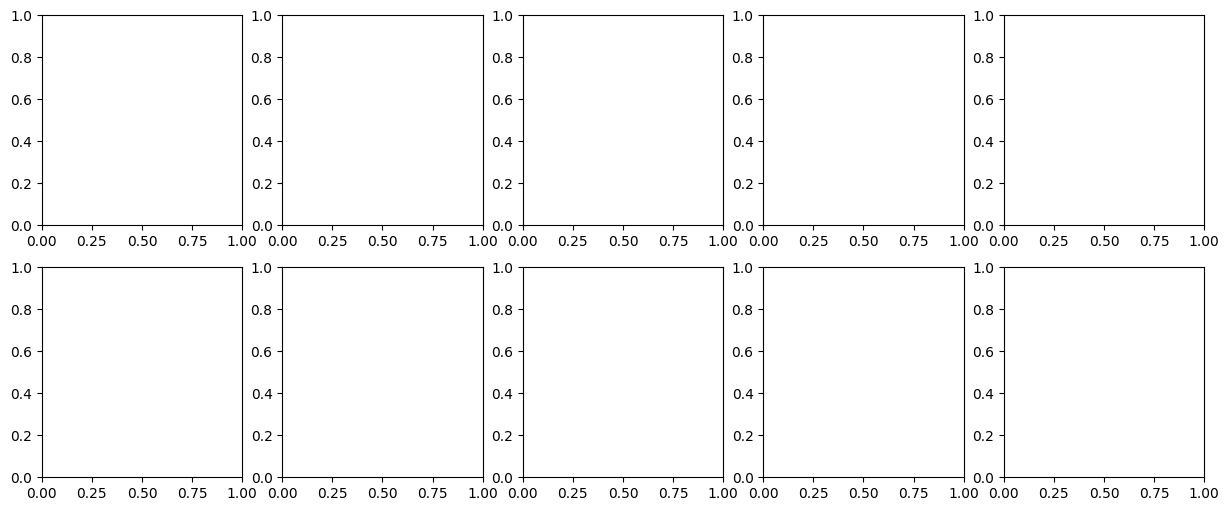

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# 隨機挑選 10 張被誤判為 N_A (背景/無手勢) 的照片來觀察原因
# True Label 不是 N_A (true != 0)，但被預測成 N_A (pred == 0)
false_na_df = result_df[(result_df['true'] != 0) & (result_df['pred'] == 0)].sample(10, random_state=42)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for idx, (_, row) in enumerate(false_na_df.iterrows()):
    img = Image.open(row['crop_path'])
    axes[idx].imshow(img)
    axes[idx].set_title(f"True: {row['true_name']}\nPred: N_A")
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Export Misclassifications
Export and zip the incorrectly predicted samples into labeled folders for qualitative analysis (e.g. `True_palm_Pred_NA`).

In [ ]:
import os
import shutil
from pathlib import Path
from tqdm.notebook import tqdm

# 剛剛執行的 evaluate_detailed (純模型) 存在 result_df
result_df_pure = result_df.copy()
# 因為 test_loader 設定 shuffle=False，所以順序會跟 test_df 完全一致，可以直接把路徑貼過來
result_df_pure['crop_path'] = test_df['crop_path'].values

# 設定匯出的主資料夾
EXPORT_DIR = Path("./error_analysis_shuf")
if 'google.colab' in sys.modules:
    EXPORT_DIR = Path("/content/error_analysis_shuf")

def export_errors_to_folders(df, subfolder_name):
    # 篩選出所有預測錯誤的樣本 (True 不等於 Pred)
    error_df = df[df['true'] != df['pred']]

    base_out_dir = EXPORT_DIR / subfolder_name

    print(f"正在匯出 {subfolder_name} 的錯誤圖片，共 {len(error_df)} 張...")
    for _, row in tqdm(error_df.iterrows(), total=len(error_df)):
        true_name = row['true_name']
        pred_name = row['pred_name']

        # 建立分類原因的資料夾，例如 "True_palm_Pred_NA"
        category_dir = base_out_dir / f"True_{true_name}_Pred_{pred_name}"
        category_dir.mkdir(parents=True, exist_ok=True)

        # 複製圖片過去
        src_path = Path(row['crop_path'])
        if src_path.exists():
            dst_path = category_dir / src_path.name
            shutil.copy2(src_path, dst_path)

# 首先匯出「純模型 (Pure Model)」的錯誤
export_errors_to_folders(result_df_pure, "pure_model_errors")

正在匯出 pure_model_errors 的錯誤圖片，共 432 張...


  0%|          | 0/432 [00:00<?, ?it/s]

In [ ]:
# 剛剛跑完 heuristic 的預測結果現在已經在 result_df 中了
result_df_heuristic = result_df.copy()

# 由於 evaluate_predict_on_df 已經把 crop_path 記錄在 result_df 裡面，我們可以直接匯出
export_errors_to_folders(result_df_heuristic, "heuristic_errors_shuf")

# 若要在 Colab 上直接下載，可以打包成 zip
if 'google.colab' in sys.modules:
    print("\n[Colab 環境] 正在將分類錯誤的資料夾打包成 ZIP 檔...")
    import shutil
    shutil.make_archive("/content/error_analysis_shuf", 'zip', "/content/error_analysis_shuf")
    print("打包完成，可以在 Colab 左側的 '檔案' 列表中找到 error_analysis_shuf.zip 並按右鍵下載")
else:
    print(f"\n[本機環境] 分類完成！請到 {EXPORT_DIR.absolute()} 裡面查看。")

正在匯出 heuristic_errors_shuf 的錯誤圖片，共 432 張...


  0%|          | 0/432 [00:00<?, ?it/s]

KeyError: 'crop_path'

In [ ]:
!zip -r models_v3aug_baldataset.zip models

  adding: models/ (stored 0%)
  adding: models/fusion_shufflenetv2_landmark_augv3_15k_detect_80ep_best_SVD.pth (deflated 18%)
  adding: models/fusion_shufflenetv2_lowrank_r96_fp16.pth (deflated 16%)
  adding: models/fusion_shufflenetv2_lowrank_r64_fp16.pth (deflated 16%)
  adding: models/fusion_shufflenetv2_lowrank_r16_fp16.pth (deflated 18%)
  adding: models/fusion_shufflenetv2_landmark_augv3_15k_detect_80ep_best.pth (deflated 12%)
  adding: models/fusion_shufflenetv2_lowrank_r32_fp16.pth (deflated 17%)


In [ ]:
from google.colab import files
files.download('models_v3aug_baldataset.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>